<a href="https://www.kaggle.com/code/leonardoterra/ai-usage-vs-gpa-improvement-eda?scriptVersionId=324775554" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/leonardoterra" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

**Dataset**
--

# **AI Usage vs GPA Improvement**
    Data Science EDA
    
### **Data Description**
This analysis is based on a dataset extracted from Kaggle.com. This dataset presents data related to student AI tool usage in 2026, including GPA before and after AI adoption, primary tools used, main usage cases, time saved, and ethics concerns. The goal of this analysis is to evaluate whether AI usage has a meaningful impact on academic performance and to explore behavioral patterns across different student majors.

## **Import Libraries**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+E
# nter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
'''
Run on Kaggle or Google Colab
#df = pd.read_csv('/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv')
'''

#Run it locally
import kagglehub
kagglehub.login()

from pathlib import Path
path = kagglehub.dataset_download("sohaibdevv/ai-and-student-life-2026-the-new-normal")
csv_path = Path(path) / "AI_Impact_Student_Life_2026.csv"

df = pd.read_csv(csv_path)
df

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9
...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7


## **EDA**

### **Data Exploration**
    During this step we can explore the shape of the data we are working with. It's usual to check and deal with the number of columns and rows, missing values, outliers and other inconsistencies that might appear.
--

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   object 
 3   Primary_AI_Tool          1500 non-null   object 
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   object 
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   object 
 10  Career_Confidence_Score  1500 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 129.0+ KB


In [5]:
data_assessment = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [df[col].dtype for col in df.columns],
    "Missing Values": [f"{df[col].isna().mean() * 100:.1f}%" for col in df.columns],
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Example Value": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns]
})
data_assessment

,Column,Data Type,Missing Values,Unique Values,Example Value
0,Student_ID,object,0.0%,1500,STU-6019
1,Age,int64,0.0%,8,23
2,Major,object,0.0%,6,Software Engineering
3,Primary_AI_Tool,object,0.0%,5,Gemini Pro
4,Task_Frequency_Daily,int64,0.0%,10,1
5,Main_Usage_Case,object,0.0%,5,Code Debugging
6,GPA_Baseline,float64,0.0%,151,2.62
7,GPA_Post_AI,float64,0.0%,187,2.62
8,Time_Saved_Hours_Weekly,int64,0.0%,14,9
9,AI_Ethics_Concern,object,0.0%,3,Medium


In [6]:
feature = {
    "Student_ID": "A unique identifier for each student.",
    "Age": "Age of the student, ranging from 18 to 25 years.",
    "Major": "The student's field of study (e.g., Software Engineering, Business, Arts).",
    "Primary_AI_Tool": "The main AI platform the student uses for academic work.",
    "Task_Frequency_Daily": "Estimated number of times a student interacts with AI tools per day.",
    "Main_Usage_Case": "The primary way AI is utilized (e.g., Debugging, Research, Exam Prep).",
    "GPA_Baseline": "The student's Grade Point Average before integrating AI into their study routine.",
    "GPA_Post_AI": "The student's current Grade Point Average after adopting AI tools.",
    "Time_Saved_Hours_Weekly": "Estimated hours saved per week by using AI for manual or repetitive tasks.",
    "AI_Ethics_Concern": "Level of concern regarding academic integrity and original work (Low/Medium/High)."
}

In [7]:
# GPA Improvement Delta
df['Improvement %'] = (df['GPA_Post_AI'] / df['GPA_Baseline']-1).round(2)

### **Statistical Analysis**
    This step seeks to understand the interaction and correlation among the features.
    Here's possible to check multicolinearity, plot visulizations and highlight key points.
--

#### **Feature Distribution**

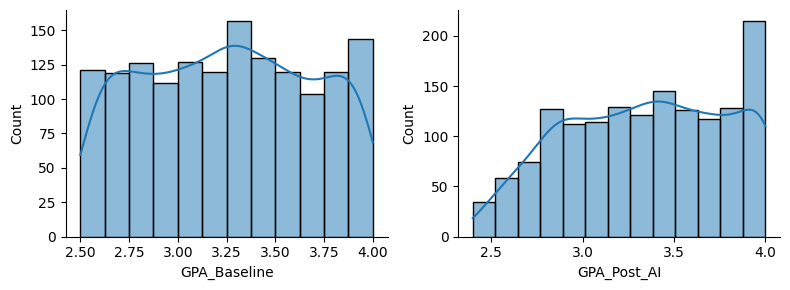

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

ax[0] = sns.histplot(data=df, x='GPA_Baseline', ax=ax[0], kde=True)
ax[1] = sns.histplot(data=df, x='GPA_Post_AI', ax=ax[1], kde=True)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

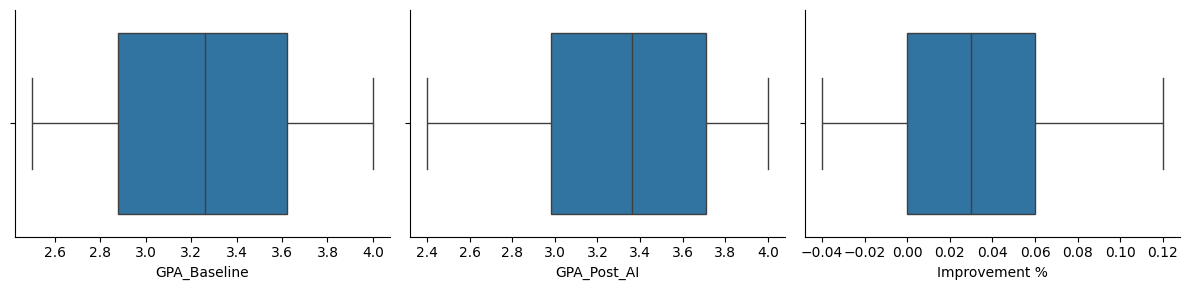

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

ax[0] = sns.boxplot(data=df, x='GPA_Baseline', ax=ax[0])
ax[1] = sns.boxplot(data=df, x='GPA_Post_AI', ax=ax[1])
ax[2] = sns.boxplot(data=df, x='Improvement %', ax=ax[2])

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

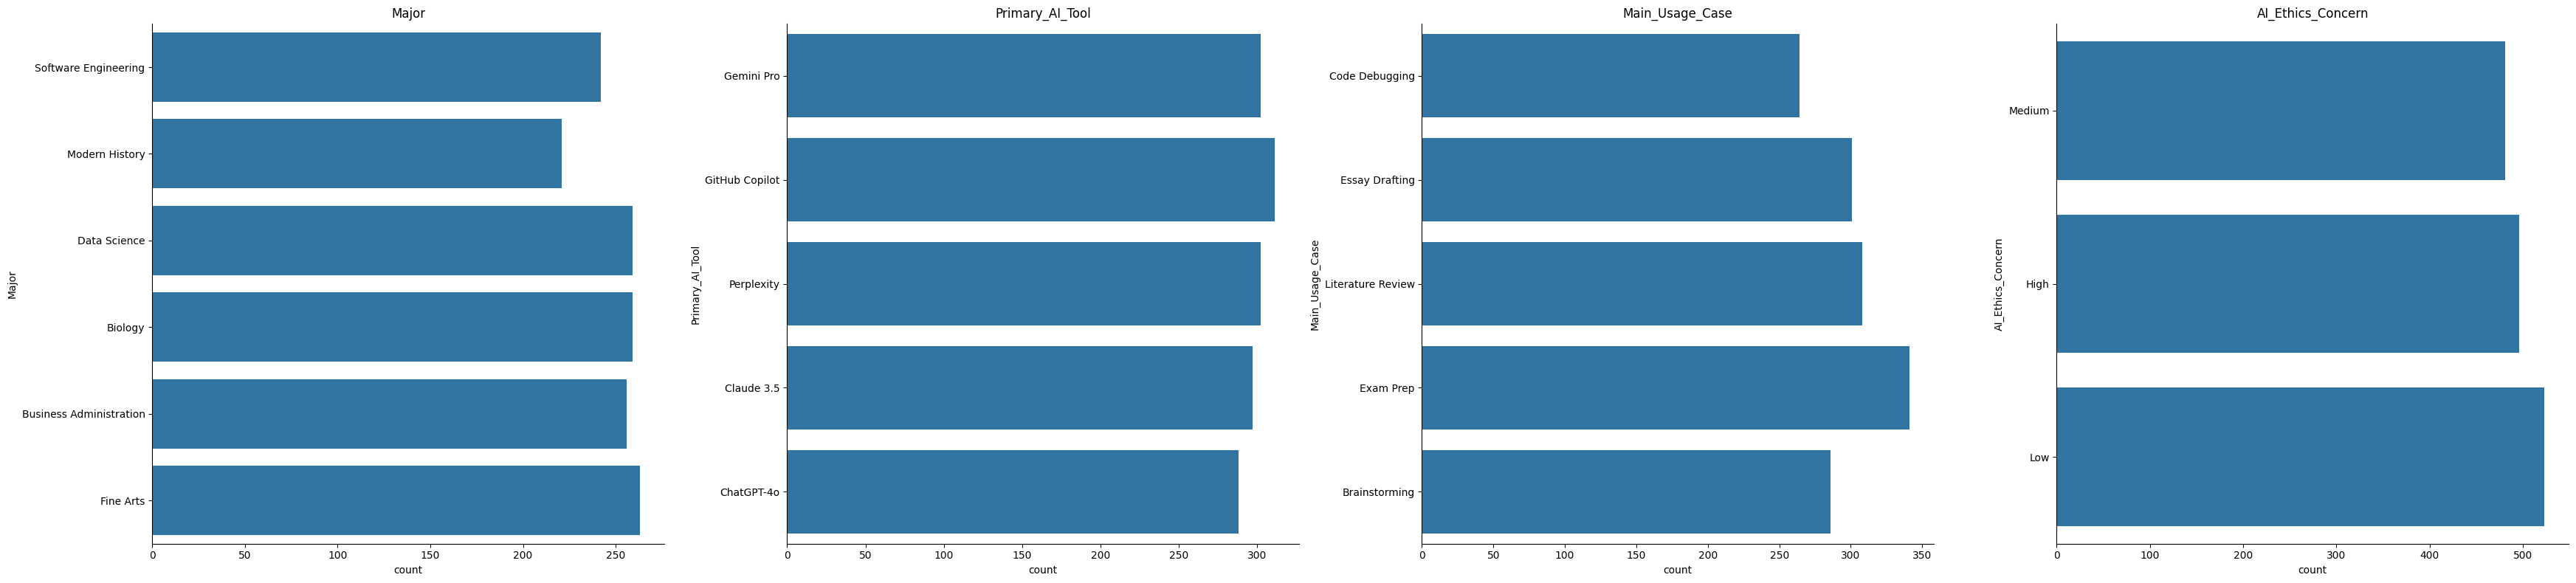

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = df.drop(['Student_ID','Age','Task_Frequency_Daily','Task_Frequency_Daily','GPA_Baseline','GPA_Post_AI','Time_Saved_Hours_Weekly','Career_Confidence_Score'], axis=1).columns.to_list()

fig, axes = plt.subplots(1, 4, figsize=(35, 8))

for ax, col in zip(axes.flatten(), cols):
    sns.countplot(data=df, y=col, ax=ax)
    ax.set_title(col)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

    Github Copilot is the most used AI overall followed by Gemini Pro and Perplexity.
    The main usage of the models goes to Exam Prep, followed by Literature Review and Essay Drafting.

In [11]:
# Baseline GPA x After AI GPA

df[['GPA_Baseline', 'GPA_Post_AI']].mean().round(2)

GPA_Baseline    3.26
GPA_Post_AI     3.34
dtype: float64

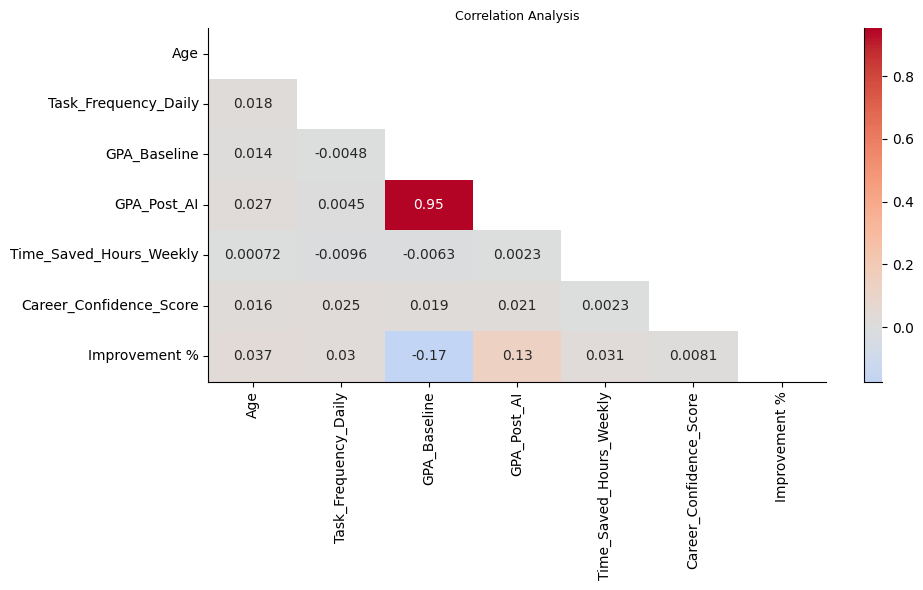

In [12]:
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Mask to remove the upper side and facilitate visualization

plt.figure(figsize=(10,6))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.title("Correlation Analysis", fontsize=9)
plt.tight_layout()

#### **Paired Distributions**
    Checking Majors against many features to see how each field performs before and after AI, as well as how they use it.

##### **Primary AI tool by Major**

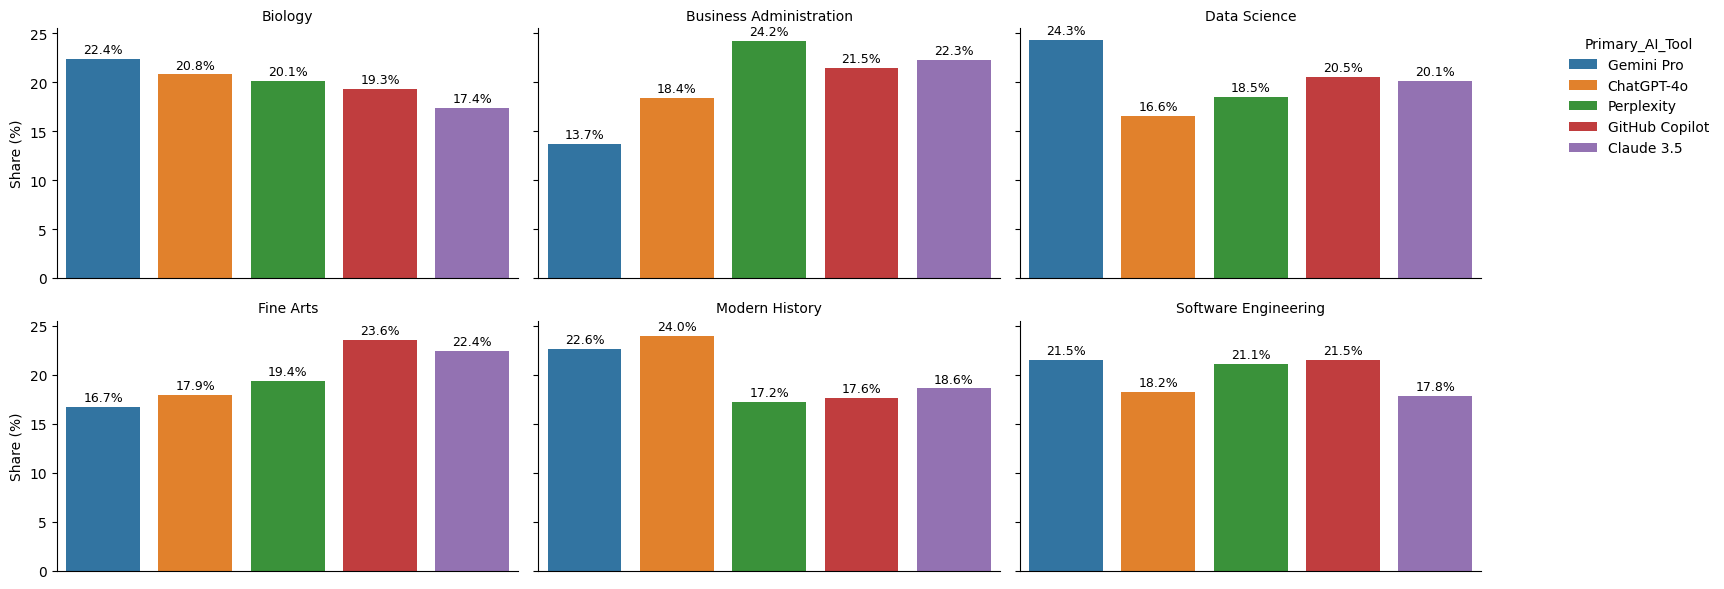

In [13]:
# Dataframe
major_tool = (df.groupby('Major')['Primary_AI_Tool'].value_counts(normalize=True).round(3)*100).reset_index()
major_tool.rename(columns={'proportion':'share'}, inplace=True)

# Plot
axes = sns.catplot(data=major_tool, x='Primary_AI_Tool', y='share', col='Major', hue='Primary_AI_Tool', col_wrap=3, kind='bar', height=3, aspect=1.5, legend=True)
axes.set_axis_labels('', 'Share (%)')
axes.set_titles(col_template='{col_name}')

for ax in axes.axes.flat:
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.3,
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9
            )

sns.move_legend(axes, loc='upper right', bbox_to_anchor=(1.15, 0.95))
sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

##### **Main use case by Major**

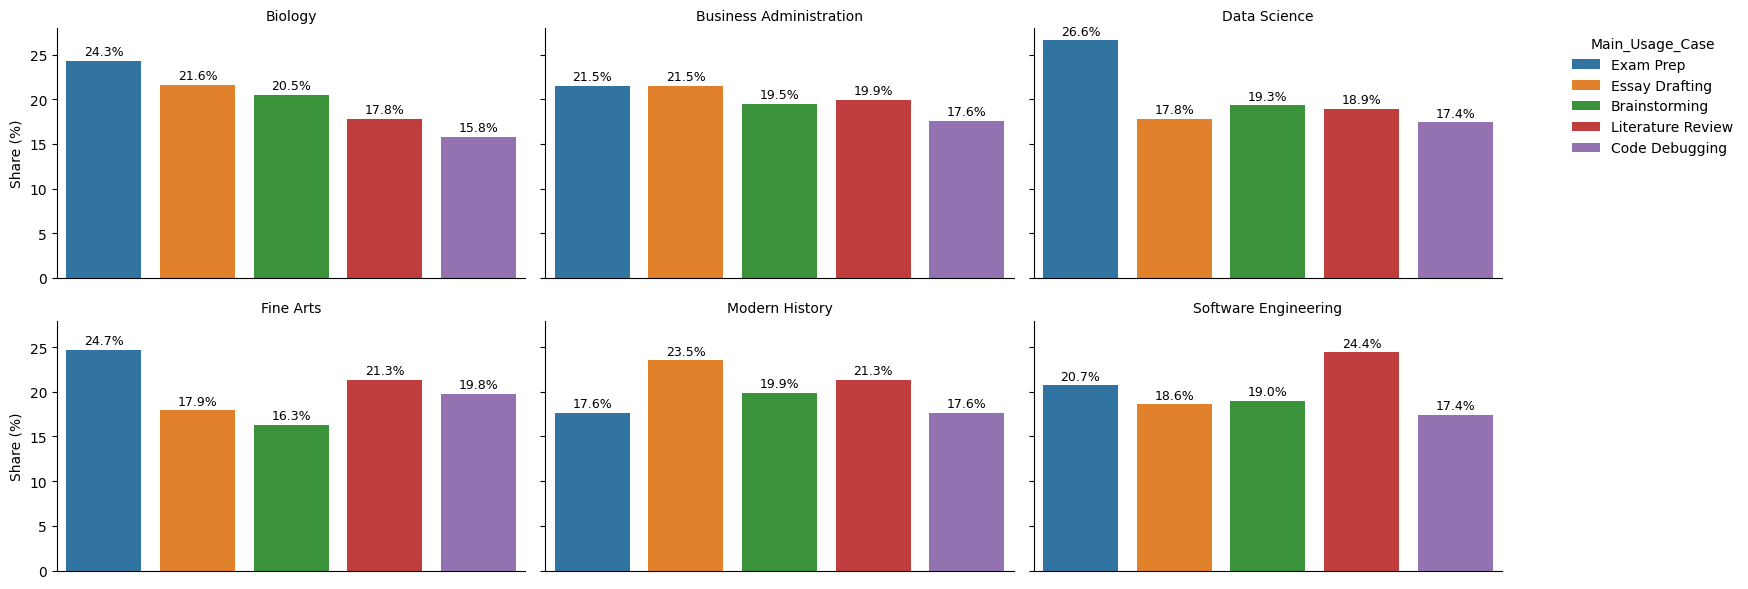

In [14]:
# Dataframe
major_use_case = (df.groupby('Major')['Main_Usage_Case'].value_counts(normalize=True).round(3)*100).reset_index()
major_use_case.rename(columns={'proportion':'share'}, inplace=True)

# Plot
axes = sns.catplot(data=major_use_case, x='Main_Usage_Case', y='share', col='Major', hue='Main_Usage_Case', col_wrap=3, kind='bar', height=3, aspect=1.5, legend=True)
axes.set_axis_labels('', 'Share (%)')
axes.set_titles(col_template='{col_name}')

for ax in axes.axes.flat:
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.3,
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9
            )

sns.move_legend(axes, loc='upper right', bbox_to_anchor=(1.15, 0.95))
sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

##### **Ethics concern by Major**

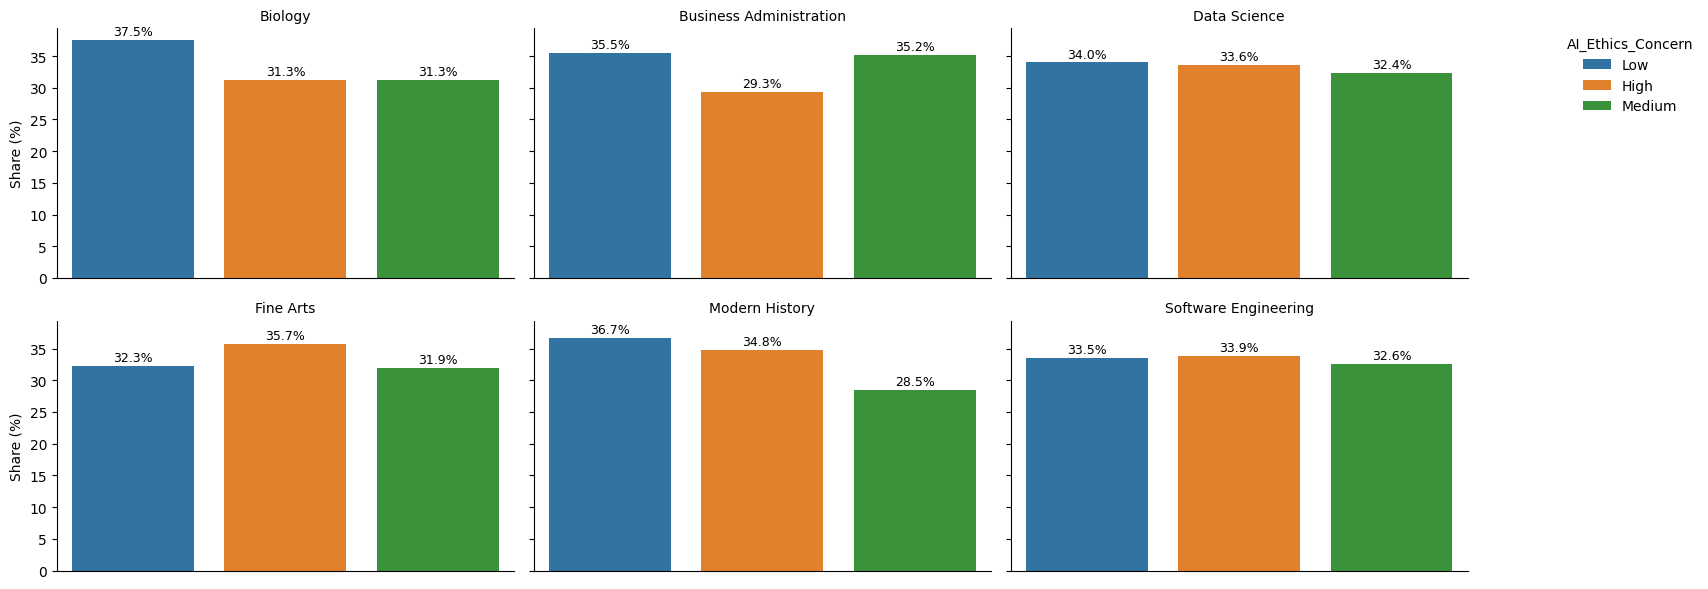

In [15]:
# Dataframe
major_ethics = (df.groupby('Major')['AI_Ethics_Concern'].value_counts(normalize=True).round(3)*100).reset_index()
major_ethics.rename(columns={'proportion':'share'}, inplace=True)

# Plot
axes = sns.catplot(data=major_ethics, x='AI_Ethics_Concern', y='share', col='Major', hue='AI_Ethics_Concern', col_wrap=3, kind='bar', height=3, aspect=1.5, legend=True)
axes.set_axis_labels('', 'Share (%)')
axes.set_titles(col_template='{col_name}')

for ax in axes.axes.flat:
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.3,
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9
            )

sns.move_legend(axes, loc='upper right', bbox_to_anchor=(1.15, 0.95))
sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

##### **GPA improvement After AI**

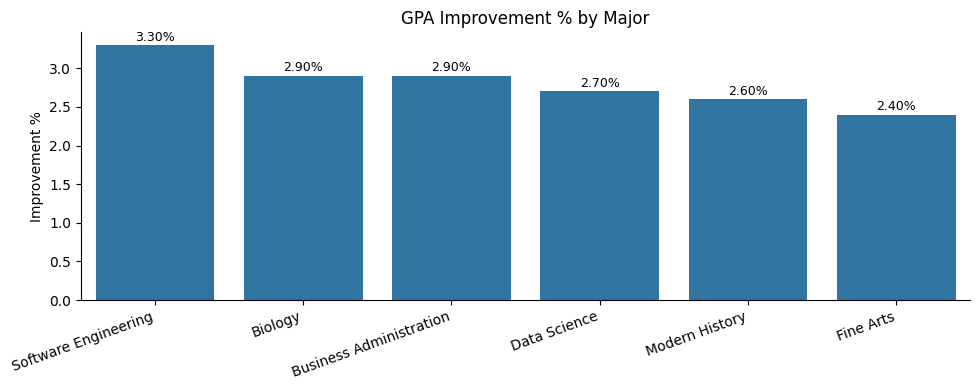

In [16]:
# Dataframe

major_gpa = (df.groupby('Major')['Improvement %'].mean().round(3)*100).reset_index()
order = major_gpa.sort_values('Improvement %', ascending=False)['Major'].tolist()

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.barplot(data=major_gpa, x='Major', y='Improvement %', order=order)
ax.set_title('GPA Improvement % by Major')
ax.set_xlabel('')

ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

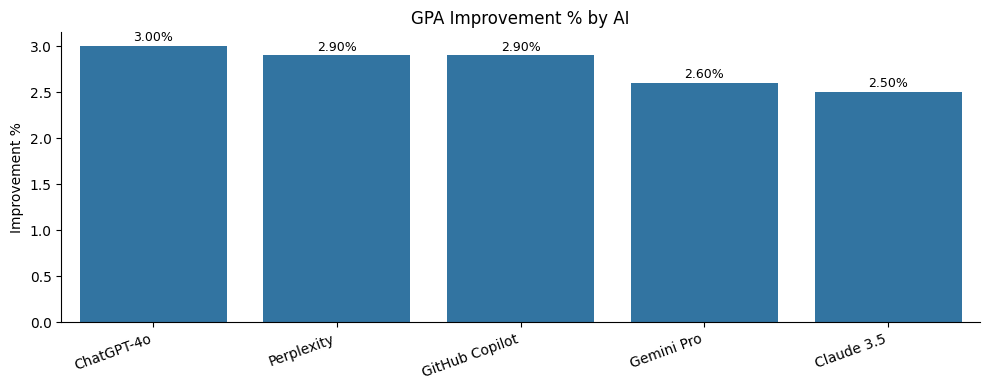

In [17]:
# Dataframe

ai_gpa = (df.groupby('Primary_AI_Tool')['Improvement %'].mean().round(3) * 100).reset_index()
order = ai_gpa.sort_values('Improvement %', ascending=False)['Primary_AI_Tool'].tolist()

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.barplot(data=ai_gpa, x='Primary_AI_Tool', y='Improvement %', order=order)
ax.set_title('GPA Improvement % by AI')
ax.set_xlabel('')

ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.2f}%', ha='center', va='bottom',
                fontsize=9)

sns.despine(left=False, right=True, top=True, bottom=False)
plt.tight_layout()

## **Insights:**
--

#### **Statistics**:

* Analysis performed using synthetic data. Findings might not express real world situations. No strong correlations found among numeric features.
* Data shows GPA improvement post AI tools. The increase is not meaningful. It goes from 3.26 to 3.34.
* Copilot is the most used AI, followed by Gemini Pro and Perplexity. Differences between tools are small and the data is synthetic
* The main usage of the models goes to Exam Prep, followed by Literature Review and Essay Drafting.
* Fine arts is the field that is more concerned about ethics while Biology is the least.
* Software engineering is the field that shows the biggest GPA improvement after AI, followed by Biology and Business Admin.
* ChatGPT is the AI tool that brings more average improvement, followed by Perplexity and Copilot.

### **Hypothesis Tests**
--

#### Wilcoxon Test
    Non-parametric statistical test used to compare two related (paired) samples (Before and After)

##### **Hypotheses**

- **Null Hypothesis (H₀)**: The **median difference** between paired observations is **zero** (no change).
- **Alternative Hypothesis (H₁)**: The median difference **is not zero** (there is a change).

In [18]:
GPA_test = df[['GPA_Baseline','GPA_Post_AI']]
GPA_test

from scipy.stats import wilcoxon

# Wilcoxon signed-rank test
stat, p = wilcoxon(GPA_test['GPA_Baseline'], GPA_test['GPA_Post_AI'])

print(f"Statistic = {stat:.4f}, p-value = {p:.4f}")

Statistic = 102986.5000, p-value = 0.0000


#### **Insights:**
--

#### **Statistics**:

* Both Hypothesis tests were successful to reject H0, which means that there's a valid change regarding GPA scores post AI usage.

# **Thank You for taking the time to view this Notebook**!

If you found this analysis useful and have any feedback or suggestions, don't hesitate to contact me! We are here to learn!